# Laboratorium 7: Klasteryzacja

Dry Bean Dataset - 13611 ziaren fasoli, 7 gatunkow, 16 cech geometrycznych. Porownanie k-srednich i klasteryzacji aglomeracyjnej.

## Importy i funkcje pomocnicze

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

RNG = 42
np.random.seed(RNG)
DATA_PATH = Path('Dry_Bean_Dataset.arff')

In [2]:
def purity_score(labels_true, labels_pred):
    cont = contingency_matrix(labels_true, labels_pred)
    return cont.max(axis=0).sum() / cont.sum()


def decode_class(s):
    if isinstance(s, bytes):
        return s.decode('utf-8')
    return s

## Zadanie 1: Analiza zbioru danych

Wczytanie z formatu ARFF (scipy.io.arff). Zbior ma cechy na roznych skalach - Area idzie w setki tysiecy, ShapeFactor1 to ulamek - więc do klasteryzacji euklidesowej trzeba bedzie skalowac.

In [3]:
source = arff.loadarff(DATA_PATH)
df = pd.DataFrame(source[0])
df['Class'] = df['Class'].apply(decode_class)

print(f'Wierszy: {df.shape[0]}, kolumn: {df.shape[1]} (16 cech + Class)')
print(f'Braki: {df.isnull().sum().sum()}')
print(f'Duplikaty: {df.duplicated().sum()}')
df.head()

Wierszy: 13611, kolumn: 17 (16 cech + Class)
Braki: 0
Duplikaty: 68


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Rozklad klas:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Liczba klas: 7


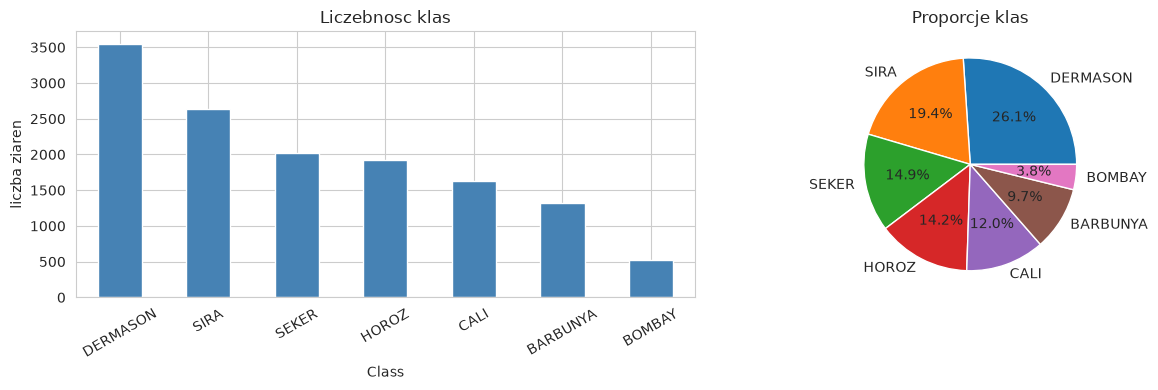

In [4]:
print('Rozklad klas:')
print(df['Class'].value_counts())
print(f'\nLiczba klas: {df["Class"].nunique()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Liczebnosc klas'); ax1.set_ylabel('liczba ziaren')
ax1.tick_params(axis='x', rotation=30)
df['Class'].value_counts(normalize=True).plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_ylabel(''); ax2.set_title('Proporcje klas')
plt.tight_layout(); plt.show()

In [5]:
feat_cols = [c for c in df.columns if c != 'Class']
print(f'Liczba cech numerycznych: {len(feat_cols)}')
df[feat_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)

Liczba cech numerycznych: 16


,mean,std,min,max
Area,53048.285,29324.096,20420.000,254616.000
Perimeter,855.283,214.290,524.736,1985.370
MajorAxisLength,320.142,85.694,183.601,738.860
MinorAxisLength,202.271,44.970,122.513,460.198
AspectRation,1.583,0.247,1.025,2.430
Eccentricity,0.751,0.092,0.219,0.911
ConvexArea,53768.200,29774.916,20684.000,263261.000
EquivDiameter,253.064,59.177,161.244,569.374
Extent,0.750,0.049,0.555,0.866
Solidity,0.987,0.005,0.919,0.995


Rozstrzal skal (max-min):
TOP5:
ConvexArea         242577.00
Area               234196.00
Perimeter            1460.63
MajorAxisLength       555.26
EquivDiameter         408.13
dtype: float64

BOTTOM5:
Extent          0.3109
Solidity        0.0754
ShapeFactor4    0.0520
ShapeFactor1    0.0077
ShapeFactor2    0.0031
dtype: float64


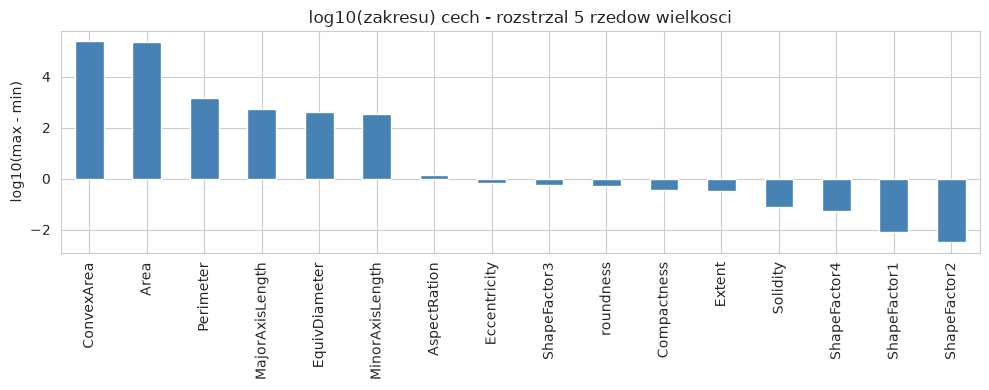

In [6]:
ranges = (df[feat_cols].max() - df[feat_cols].min()).sort_values(ascending=False)
print('Rozstrzal skal (max-min):')
print('TOP5:'); print(ranges.head(5).round(2))
print('\nBOTTOM5:'); print(ranges.tail(5).round(4))

fig, ax = plt.subplots(figsize=(10, 4))
np.log10(ranges).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('log10(zakresu) cech - rozstrzal 5 rzedow wielkosci')
ax.set_ylabel('log10(max - min)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

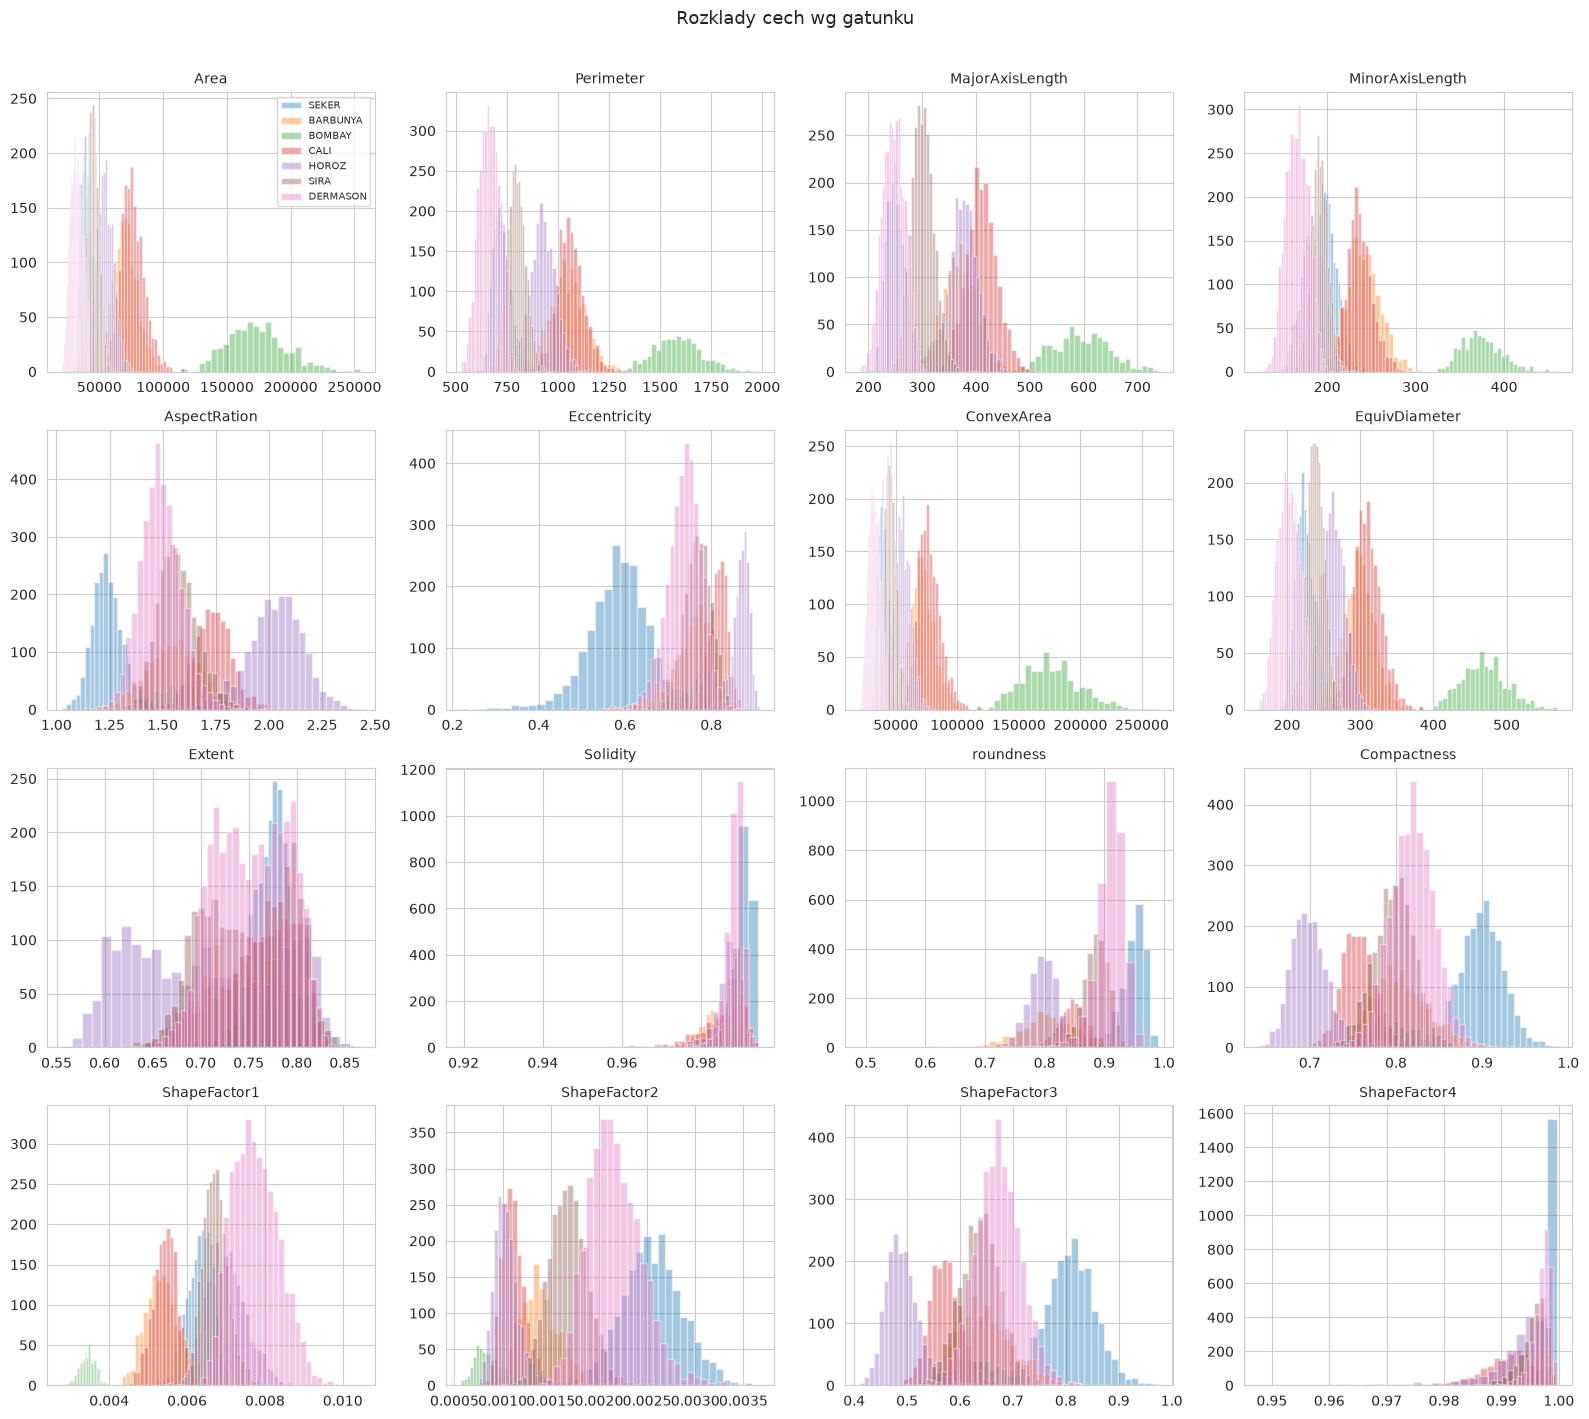

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.ravel(), feat_cols):
    for cls in df['Class'].unique():
        ax.hist(df[df['Class'] == cls][col], bins=30, alpha=0.4, label=cls)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
axes[0, 0].legend(fontsize=7, loc='upper right')
plt.suptitle('Rozklady cech wg gatunku', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

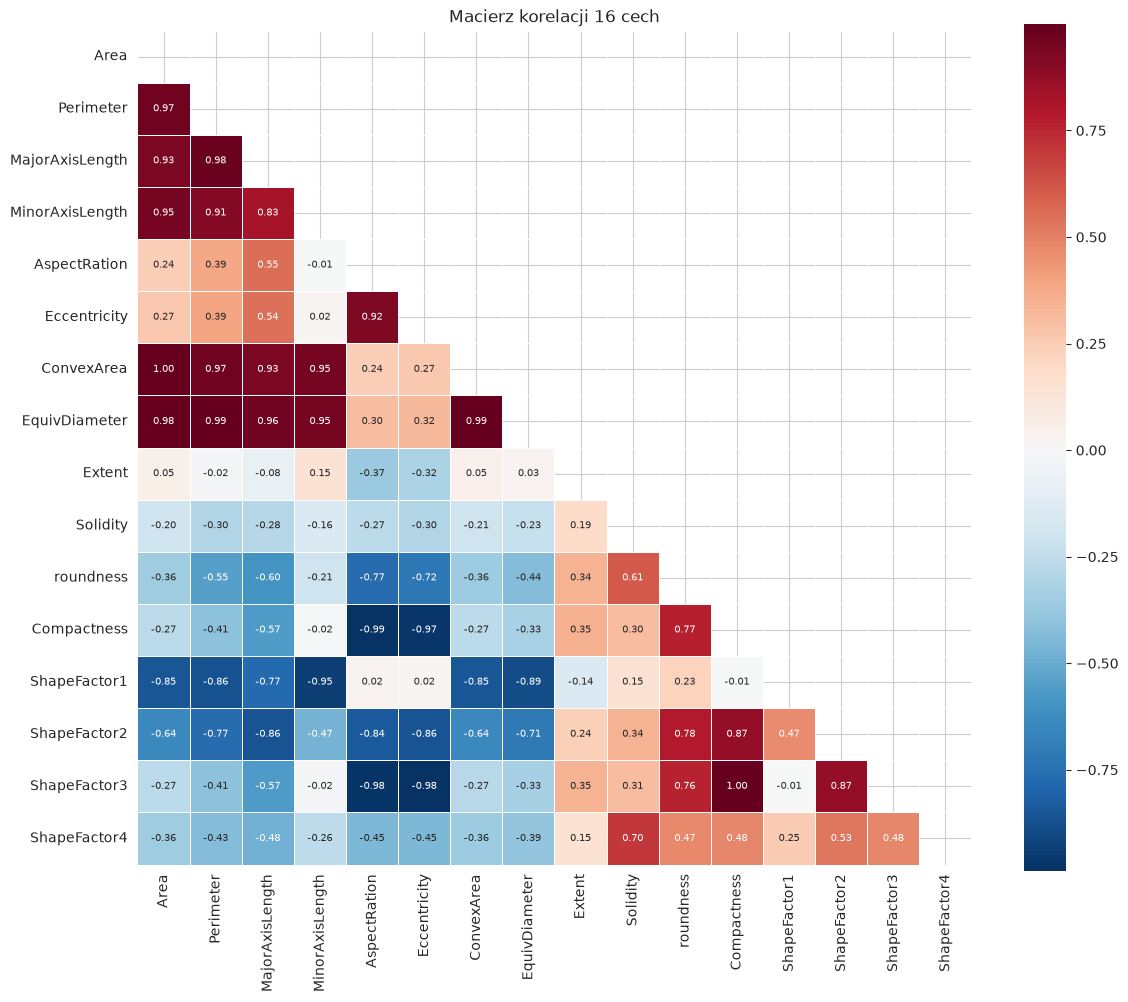

Najbardziej skorelowane pary:
Area         ConvexArea         1.000
Compactness  ShapeFactor3       0.999
Perimeter    EquivDiameter      0.991
ConvexArea   EquivDiameter      0.985
Area         EquivDiameter      0.985
Perimeter    MajorAxisLength    0.977
             ConvexArea         0.968
Area         Perimeter          0.967
dtype: float64


In [8]:
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Macierz korelacji 16 cech')
plt.tight_layout(); plt.show()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
               .stack().sort_values(ascending=False))
print('Najbardziej skorelowane pary:')
print(corr_pairs.head(8).round(3))

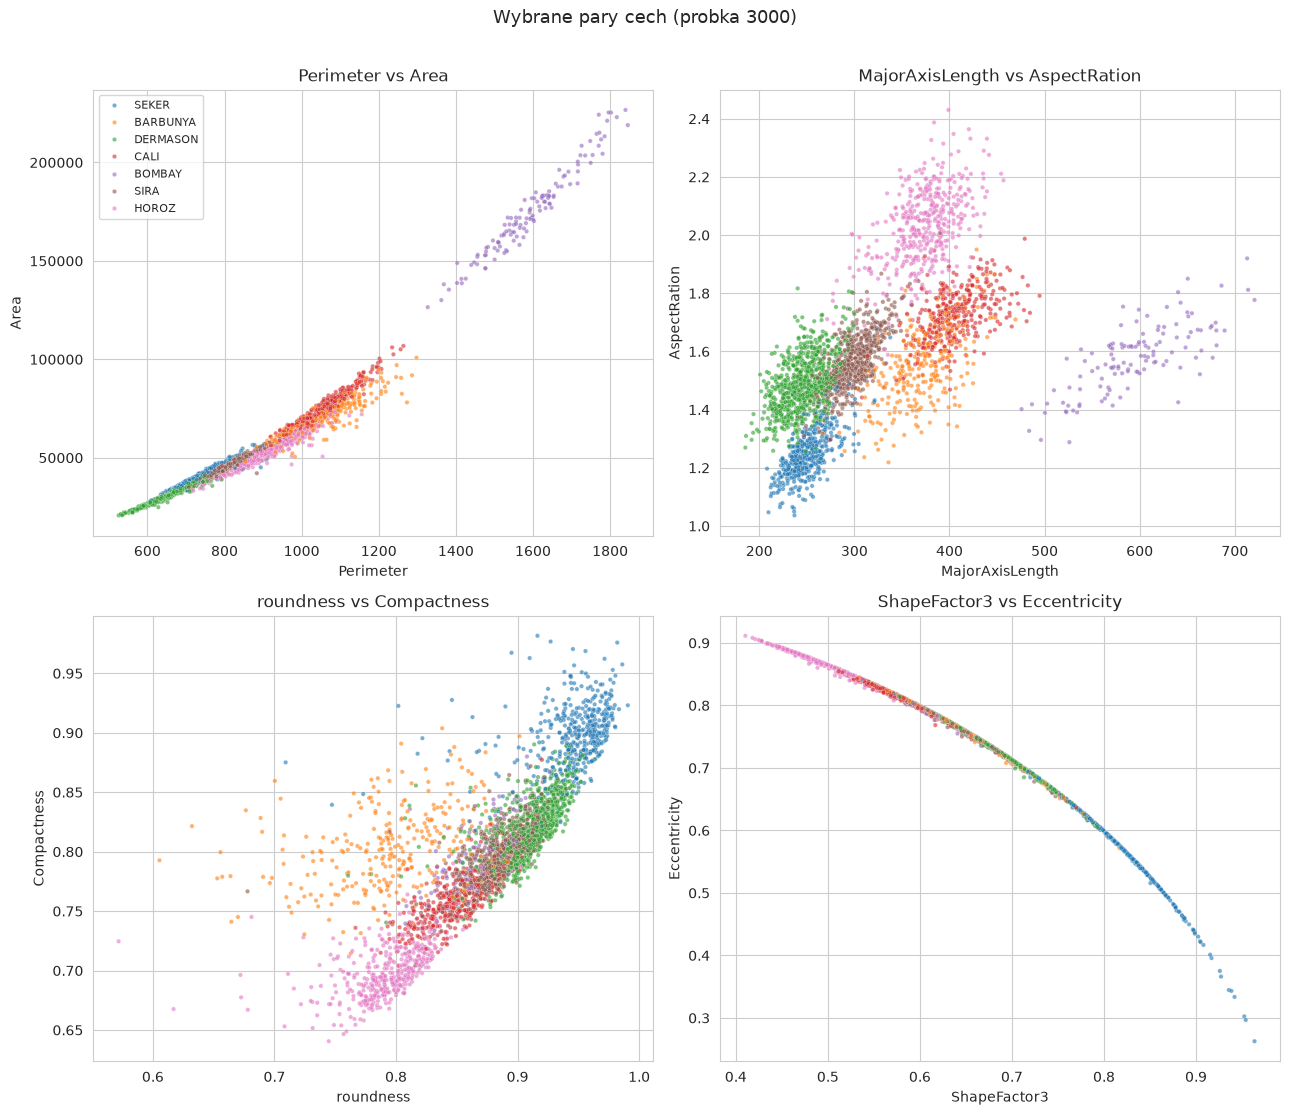

In [9]:
interesting_pairs = [
    ('Perimeter', 'Area'),
    ('MajorAxisLength', 'AspectRation'),
    ('roundness', 'Compactness'),
    ('ShapeFactor3', 'Eccentricity'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (x_col, y_col) in zip(axes.ravel(), interesting_pairs):
    sns.scatterplot(data=df.sample(3000, random_state=RNG),
                    x=x_col, y=y_col, hue='Class', s=10, alpha=0.6, ax=ax)
    ax.set_title(f'{x_col} vs {y_col}')
axes[0, 0].legend(fontsize=8, loc='upper left')
for ax in axes.ravel()[1:]:
    ax.legend_.set_visible(False)
plt.suptitle('Wybrane pary cech (probka 3000)', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

### Decyzje preprocessingowe

- Brak brakow danych, 68 duplikatow (realne - ziarna moga miec te same wymiary po zaokragleniu), zostawiam.
- StandardScaler - cechy na roznych skalach, bez tego KMeans/Agglomerative zdominowalby Area/Perimeter/ConvexArea.
- Outliery z klasy BOMBAY (najwieksze ziarna) zostaja - to realna czesc zbioru.
- Class to etykieta odniesienia dla purity, nie cecha.

In [10]:
X_raw = df[feat_cols].values
y_true = df['Class'].values
class_names = sorted(df['Class'].unique())

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f'X shape: {X.shape}, mean={X.mean():.2f}, std={X.std():.2f}')
print(f'Klasy: {class_names}')

pca_global = PCA(n_components=2, random_state=RNG).fit(X)
X2d = pca_global.transform(X)
print(f'PCA(2D) zachowuje {pca_global.explained_variance_ratio_.sum():.2%} wariancji')

X shape: (13611, 16), mean=0.00, std=1.00
Klasy: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
PCA(2D) zachowuje 81.90% wariancji


## Zadanie 2: Algorytm k-srednich

### 2.1: Przygotowanie

KMeans na k=4 (na start), odczyt inercji. Wizualizacja przez rzut PCA(2D) bo 16 wymiarow nie narysujesz bezposrednio.

KMeans k=4: inercja = 76474.31
Liczba iteracji: 10
Rozklad klasterow: [2221 5874  524 4992]


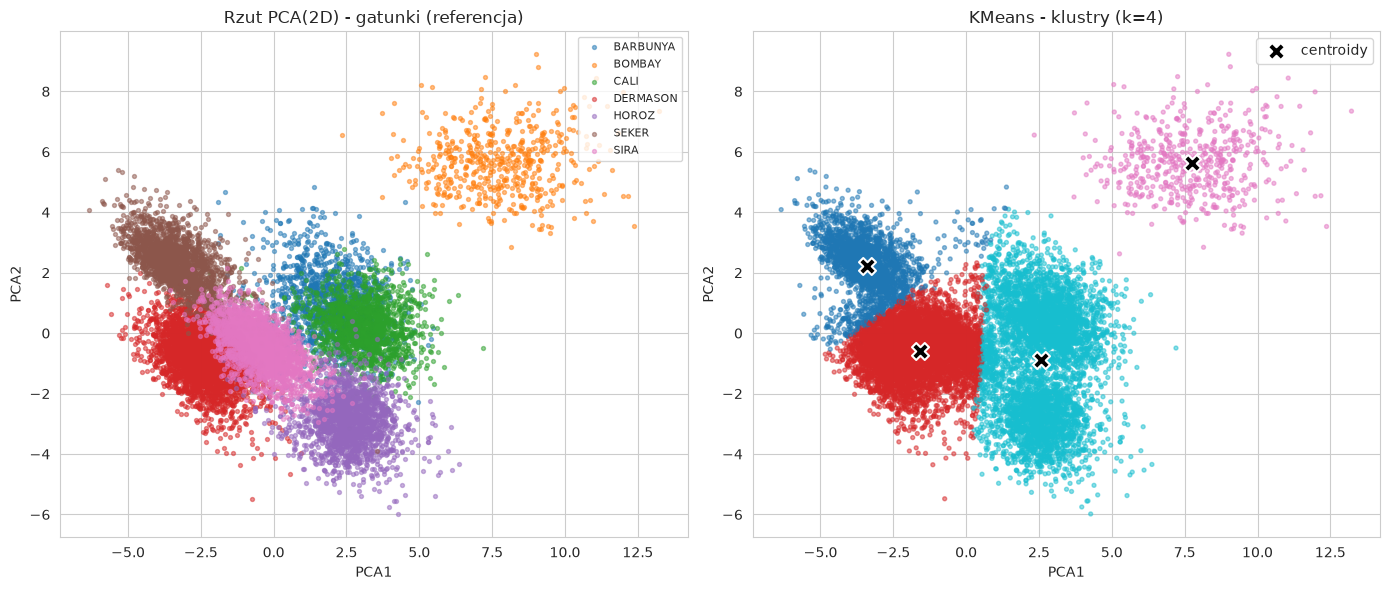

Purity dla k=4: 0.555
Silhouette dla k=4: 0.338


In [11]:
def show_clusters_2d(labels, centers_2d=None, title='', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    k = len(np.unique(labels))
    ax.scatter(X2d[:, 0], X2d[:, 1], c=labels, cmap='tab10', s=8, alpha=0.5)
    if centers_2d is not None:
        ax.scatter(centers_2d[:, 0], centers_2d[:, 1], marker='X', s=150,
                   c='black', edgecolors='white', linewidths=1.5, zorder=5, label='centroidy')
        ax.legend(loc='upper right')
    ax.set_xlabel('PCA1'); ax.set_ylabel('PCA2')
    ax.set_title(f'{title} (k={k})')
    return ax


def kmeans_centroids_2d(model):
    return pca_global.transform(model.cluster_centers_)


k_init = 4
km = KMeans(n_clusters=k_init, random_state=RNG, n_init=10)
km.fit(X)
print(f'KMeans k={k_init}: inercja = {km.inertia_:.2f}')
print(f'Liczba iteracji: {km.n_iter_}')
print(f'Rozklad klasterow: {np.bincount(km.labels_)}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for i, cls in enumerate(class_names):
    m = y_true == cls
    ax1.scatter(X2d[m, 0], X2d[m, 1], s=8, alpha=0.5, label=cls)
ax1.set_title('Rzut PCA(2D) - gatunki (referencja)')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_xlabel('PCA1'); ax1.set_ylabel('PCA2')
show_clusters_2d(km.labels_, centers_2d=kmeans_centroids_2d(km),
                 title='KMeans - klustry', ax=ax2)
plt.tight_layout(); plt.show()

print(f'Purity dla k={k_init}: {purity_score(y_true, km.labels_):.3f}')
print(f'Silhouette dla k={k_init}: {silhouette_score(X, km.labels_, sample_size=3000, random_state=RNG):.3f}')

### 2.2: Wplyw parametru k

Dla k od 2 do 12 mierze:
- inercje (maleje z k, szukamy lokcia)
- silhouette (im blizej 1 tym lepiej)
- purity (zgodnosc z etykietami - pamietac ze to oszukiwanie bo etykiety mamy)

In [12]:
k_range = range(2, 13)
km_results = {'k': [], 'inertia': [], 'silhouette': [], 'purity': [], 'model': []}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=3000, random_state=RNG)
    pur = purity_score(y_true, labels)
    km_results['k'].append(k)
    km_results['inertia'].append(km.inertia_)
    km_results['silhouette'].append(sil)
    km_results['purity'].append(pur)
    km_results['model'].append(km)
    print(f'k={k:2d}: inertia={km.inertia_:>11.1f}  silhouette={sil:.3f}  purity={pur:.3f}')

km_df = pd.DataFrame({k: v for k, v in km_results.items() if k != 'model'})
km_df

k= 2: inertia=   129900.0  silhouette=0.394  purity=0.399


k= 3: inertia=    94742.0  silhouette=0.403  purity=0.436


k= 4: inertia=    76474.3  silhouette=0.338  purity=0.555


k= 5: inertia=    61893.6  silhouette=0.353  purity=0.667


k= 6: inertia=    55050.1  silhouette=0.355  purity=0.656


...

k= 9: inertia=    41975.6  silhouette=0.303  purity=0.870


k=10: inertia=    39810.7  silhouette=0.263  purity=0.844


k=11: inertia=    37852.2  silhouette=0.281  purity=0.859


k=12: inertia=    36263.1  silhouette=0.260  purity=0.861


,k,inertia,silhouette,purity
0,2,129900.033931,0.394376,0.398795
1,3,94741.986565,0.403029,0.436265
2,4,76474.309227,0.337834,0.555066
3,5,61893.644352,0.352802,0.667107
4,6,55050.069620,0.355425,0.656014
5,7,48811.956426,0.309844,0.798325
6,8,45241.726459,0.301755,0.867460
7,9,41975.594825,0.302806,0.869958
8,10,39810.685041,0.262784,0.844244
9,11,37852.159054,0.281015,0.859011


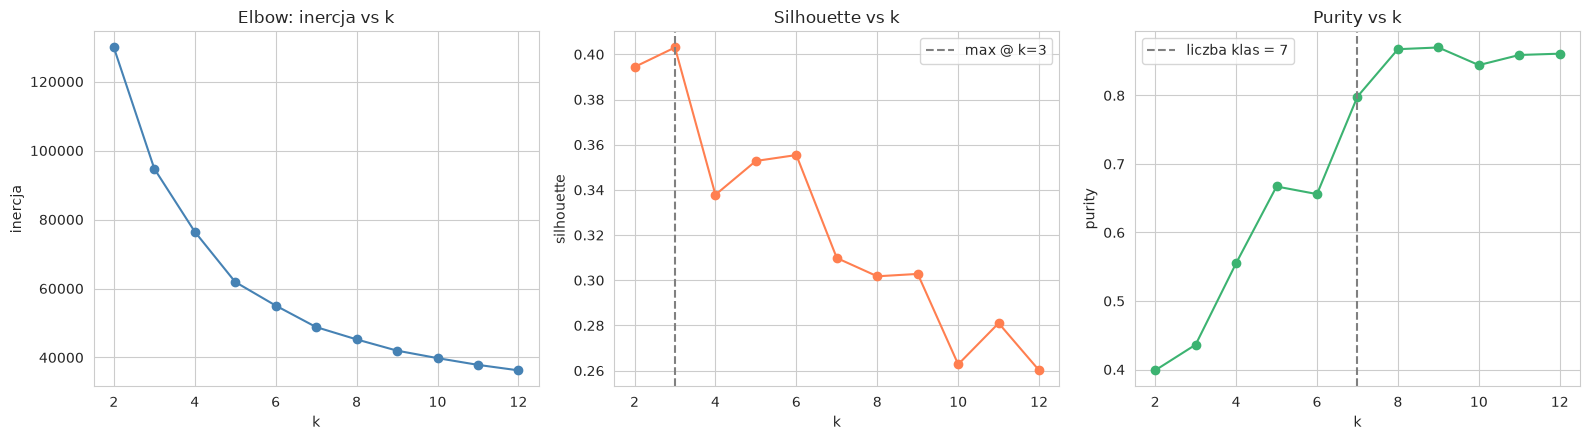

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(km_df['k'], km_df['inertia'], marker='o', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('inercja')
axes[0].set_title('Elbow: inercja vs k')

axes[1].plot(km_df['k'], km_df['silhouette'], marker='o', color='coral')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
axes[1].set_title('Silhouette vs k')
best_sil_k = km_df.loc[km_df['silhouette'].idxmax(), 'k']
axes[1].axvline(best_sil_k, color='gray', ls='--', label=f'max @ k={best_sil_k}')
axes[1].legend()

axes[2].plot(km_df['k'], km_df['purity'], marker='o', color='mediumseagreen')
axes[2].set_xlabel('k'); axes[2].set_ylabel('purity')
axes[2].set_title('Purity vs k')
axes[2].axvline(7, color='gray', ls='--', label='liczba klas = 7')
axes[2].legend()

plt.tight_layout(); plt.show()

Kluczowe k do wizualizacji: [3, 4, 7]


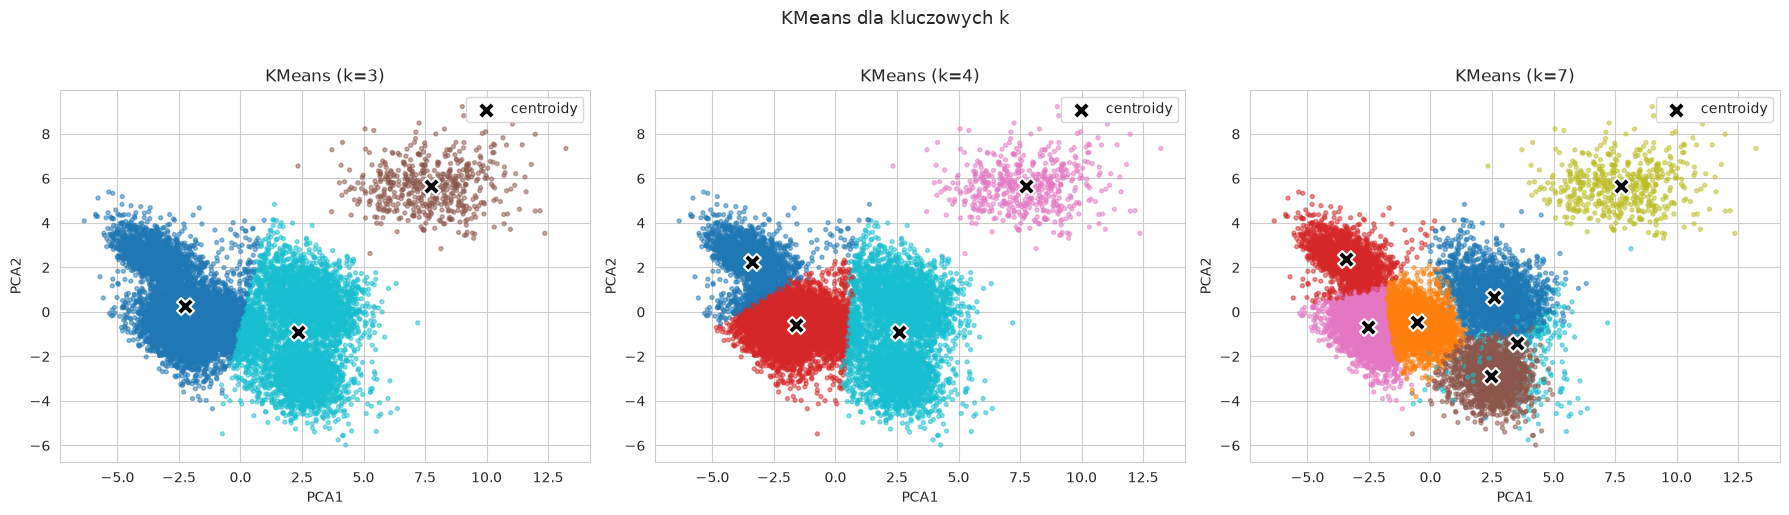

In [14]:
key_ks = sorted(set([4, 7, int(best_sil_k)]))
print(f'Kluczowe k do wizualizacji: {key_ks}')

fig, axes = plt.subplots(1, len(key_ks), figsize=(6 * len(key_ks), 5))
if len(key_ks) == 1: axes = [axes]
for ax, k in zip(axes, key_ks):
    model = km_results['model'][list(k_range).index(k)]
    show_clusters_2d(model.labels_, centers_2d=kmeans_centroids_2d(model),
                     title='KMeans', ax=ax)
plt.suptitle('KMeans dla kluczowych k', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

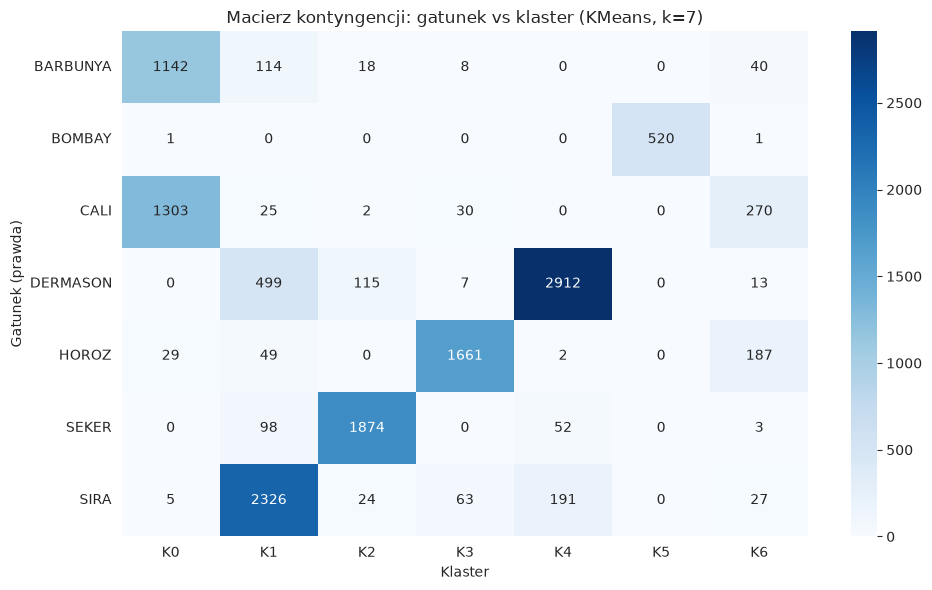

Dominujacy gatunek w klastrem:
  K0: CALI (1303 z 2480)
  K1: SIRA (2326 z 3111)
  K2: SEKER (1874 z 2033)
  K3: HOROZ (1661 z 1769)
  K4: DERMASON (2912 z 3157)
  K5: BOMBAY (520 z 520)
  K6: CALI (270 z 541)


In [15]:
best_k = 7
km_best = km_results['model'][list(k_range).index(best_k)]
cm = contingency_matrix(y_true, km_best.labels_)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'K{i}' for i in range(best_k)],
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Klaster'); ax.set_ylabel('Gatunek (prawda)')
ax.set_title(f'Macierz kontyngencji: gatunek vs klaster (KMeans, k={best_k})')
plt.tight_layout(); plt.show()

print('Dominujacy gatunek w klastrem:')
for c in range(best_k):
    dom = class_names[cm[:, c].argmax()]
    print(f'  K{c}: {dom} ({cm[:, c].max()} z {cm[:, c].sum()})')

**Co to znaczy optymalna wartosc k i jak ja wybrac?**

Nie ma jednej optymalnej - zalezy od miary. Inercja (elbow) sugeruje k~4-5 gdzie krzywa sie zlamie. Silhouette maksimum dla malych k (2-3) bo faworyzuje odseparowane kuliste klastry - a BOMBAY jest bardzo odmienny, wiec k=2 ma jeden klastrow BOMBAY-reszta. Purity rosnie az do k=7 bo tyle mamy gatunkow i algorytm to odkrywa. Bez etykiet uzywalbym elbow + silhouette + wiedze domenowa. Z etykietami - k=7 jest naturalne.

## Zadanie 3: Klasteryzacja aglomeracyjna

### 3.1: Badanie wplywu k

Ward + metryka euklidesowa (zgodnie z poleceniem). Zbadam k=2..12.

In [16]:
agg_results = {'k': [], 'silhouette': [], 'purity': [], 'model': []}

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=3000, random_state=RNG)
    pur = purity_score(y_true, labels)
    agg_results['k'].append(k)
    agg_results['silhouette'].append(sil)
    agg_results['purity'].append(pur)
    agg_results['model'].append(agg)
    print(f'k={k:2d}: silhouette={sil:.3f}  purity={pur:.3f}')

agg_df = pd.DataFrame({k: v for k, v in agg_results.items() if k != 'model'})
agg_df

k= 2: silhouette=0.390  purity=0.397


k= 3: silhouette=0.403  purity=0.435


k= 4: silhouette=0.333  purity=0.566


k= 5: silhouette=0.342  purity=0.666


k= 6: silhouette=0.275  purity=0.792


...

k= 9: silhouette=0.262  purity=0.878


k=10: silhouette=0.212  purity=0.878


k=11: silhouette=0.206  purity=0.878


k=12: silhouette=0.200  purity=0.878


,k,silhouette,purity
0,2,0.389530,0.396958
1,3,0.403099,0.435310
2,4,0.332516,0.565645
3,5,0.341787,0.665565
4,6,0.274618,0.792153
5,7,0.282539,0.798325
6,8,0.272809,0.877746
7,9,0.261954,0.877746
8,10,0.211537,0.877746
9,11,0.205861,0.877746


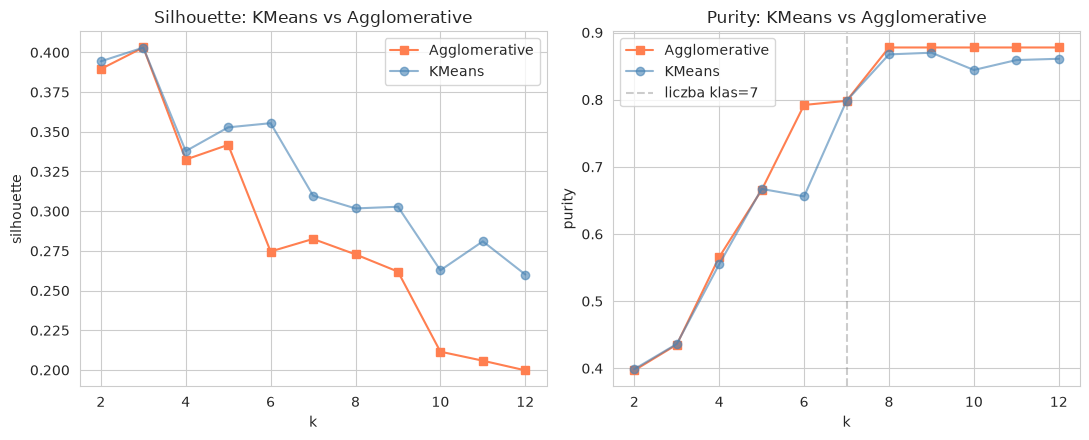

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(agg_df['k'], agg_df['silhouette'], marker='s', color='coral', label='Agglomerative')
axes[0].plot(km_df['k'], km_df['silhouette'], marker='o', color='steelblue', alpha=0.6, label='KMeans')
axes[0].set_xlabel('k'); axes[0].set_ylabel('silhouette')
axes[0].set_title('Silhouette: KMeans vs Agglomerative')
axes[0].legend()

axes[1].plot(agg_df['k'], agg_df['purity'], marker='s', color='coral', label='Agglomerative')
axes[1].plot(km_df['k'], km_df['purity'], marker='o', color='steelblue', alpha=0.6, label='KMeans')
axes[1].set_xlabel('k'); axes[1].set_ylabel('purity')
axes[1].set_title('Purity: KMeans vs Agglomerative')
axes[1].axvline(7, color='gray', ls='--', alpha=0.4, label='liczba klas=7')
axes[1].legend()

plt.tight_layout(); plt.show()

Kluczowe k dla Agglomerative: [3, 4, 7]


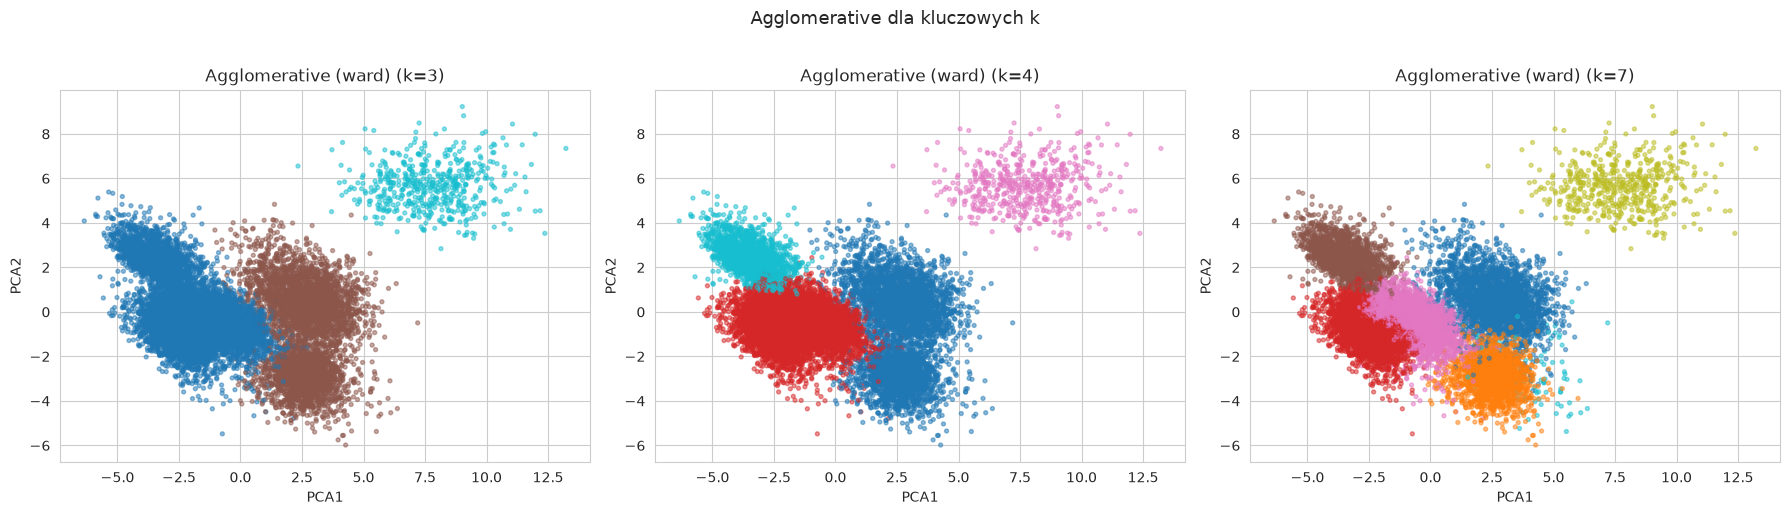

In [18]:
key_ks_agg = sorted(set([4, 7, int(agg_df.loc[agg_df['silhouette'].idxmax(), 'k'])]))
print(f'Kluczowe k dla Agglomerative: {key_ks_agg}')

fig, axes = plt.subplots(1, len(key_ks_agg), figsize=(6 * len(key_ks_agg), 5))
if len(key_ks_agg) == 1: axes = [axes]
for ax, k in zip(axes, key_ks_agg):
    model = agg_results['model'][list(k_range).index(k)]
    show_clusters_2d(model.labels_, centers_2d=None, title='Agglomerative (ward)', ax=ax)
plt.suptitle('Agglomerative dla kluczowych k', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

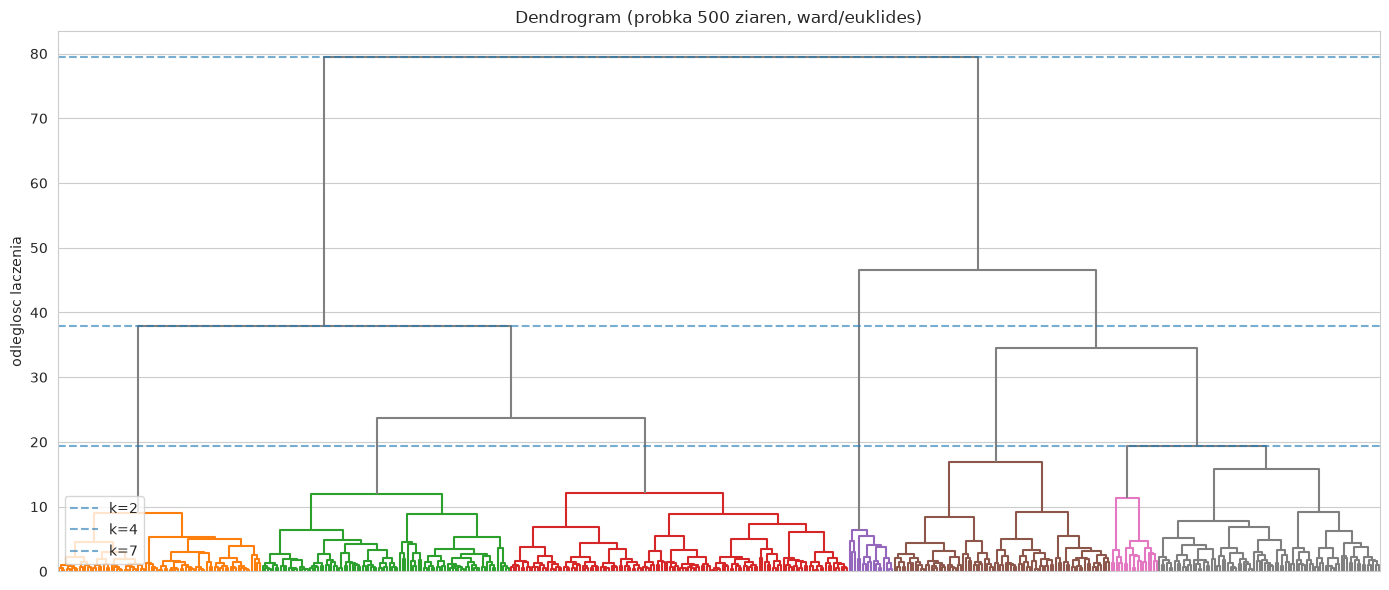

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram

sample_idx = np.random.RandomState(RNG).choice(len(X), size=500, replace=False)
X_sample = X[sample_idx]
Z = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, color_threshold=Z[-6, 2], ax=ax,
           above_threshold_color='gray')
ax.set_title('Dendrogram (probka 500 ziaren, ward/euklides)')
ax.set_ylabel('odleglosc laczenia')
for k in [2, 4, 7]:
    thr = Z[-k + 1, 2] if k > 1 else Z[:, 2].max() + 1
    ax.axhline(thr, ls='--', alpha=0.6, label=f'k={k}')
ax.legend()
plt.tight_layout(); plt.show()

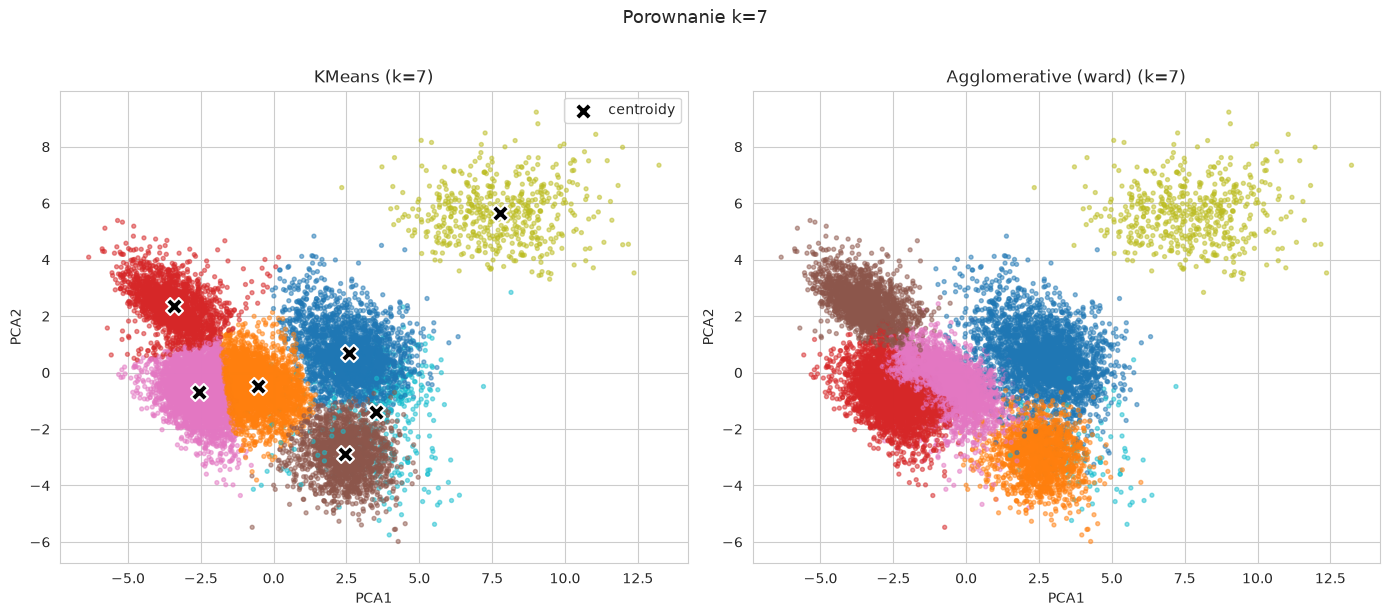

k=7:
  KMeans       - silhouette=0.310, purity=0.798


  Agglomerative- silhouette=0.283, purity=0.798


In [20]:
k_compare = 7
km_cmp = km_results['model'][list(k_range).index(k_compare)]
agg_cmp = agg_results['model'][list(k_range).index(k_compare)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
show_clusters_2d(km_cmp.labels_, centers_2d=kmeans_centroids_2d(km_cmp),
                 title='KMeans', ax=axes[0])
show_clusters_2d(agg_cmp.labels_, centers_2d=None,
                 title='Agglomerative (ward)', ax=axes[1])
plt.suptitle(f'Porownanie k={k_compare}', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print(f'k={k_compare}:')
print(f'  KMeans       - silhouette={silhouette_score(X, km_cmp.labels_, sample_size=3000, random_state=RNG):.3f}, '
      f'purity={purity_score(y_true, km_cmp.labels_):.3f}')
print(f'  Agglomerative- silhouette={silhouette_score(X, agg_cmp.labels_, sample_size=3000, random_state=RNG):.3f}, '
      f'purity={purity_score(y_true, agg_cmp.labels_):.3f}')

In [21]:
linkages = ['ward', 'complete', 'average', 'single']
link_results = []
for lk in linkages:
    try:
        m = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage=lk)
        lbl = m.fit_predict(X)
        sil = silhouette_score(X, lbl, sample_size=3000, random_state=RNG)
        pur = purity_score(y_true, lbl)
        link_results.append({'linkage': lk, 'silhouette': sil, 'purity': pur})
    except Exception as e:
        link_results.append({'linkage': lk, 'silhouette': np.nan, 'purity': np.nan, 'error': str(e)})

pd.DataFrame(link_results).round(3)

,linkage,silhouette,purity,error
0,ward,0.283,0.798,NaN
1,complete,0.232,0.505,NaN
2,average,0.352,0.303,NaN
3,single,NaN,NaN,Number of labels is 1. Valid values are 2 to n...


### 3.2: Pomiar czasu

Metodycznie poprawny pomiar: `time.perf_counter` (nie `time.time` bo ma slab rozdzielczosc), kilka powtorzen + warmup (pierwsze wywolanie ma narzut od lazy importow, inicjalizacji watkow), sprawdzam odchylenie. `timeit.timeit` tez ok ale perf_counter daje kontrole nad tym co mierze.

In [22]:
def measure_time(fn, n_runs=5, warmup=1):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.mean(times), np.std(times), times

k_time = 7
n_runs = 5

def run_kmeans():
    m = KMeans(n_clusters=k_time, random_state=RNG, n_init=10)
    m.fit(X)
    return m

def run_agg():
    m = AgglomerativeClustering(n_clusters=k_time, metric='euclidean', linkage='ward')
    m.fit(X)
    return m

print(f'Pomiar dla k={k_time}, {n_runs} powtorzen + 1 warmup, n={X.shape[0]}\n')

km_mean, km_std, km_times = measure_time(run_kmeans, n_runs=n_runs)
print(f'KMeans:        {km_mean:.3f}s ± {km_std:.3f}s  (poszczegolne: {[f"{t:.3f}" for t in km_times]}')

agg_mean, agg_std, agg_times = measure_time(run_agg, n_runs=n_runs)
print(f'Agglomerative: {agg_mean:.3f}s ± {agg_std:.3f}s  (poszczegolne: {[f"{t:.3f}" for t in agg_times]}')

print(f'\nStosunek: Agglomerative jest {agg_mean / km_mean:.1f}x wolniejszy/a od KMeans')

Pomiar dla k=7, 5 powtorzen + 1 warmup, n=13611



KMeans:        1.147s ± 0.033s  (poszczegolne: ['1.143', '1.172', '1.192', '1.133', '1.097']


Agglomerative: 5.199s ± 0.298s  (poszczegolne: ['5.168', '5.753', '4.856', '5.129', '5.089']

Stosunek: Agglomerative jest 4.5x wolniejszy/a od KMeans


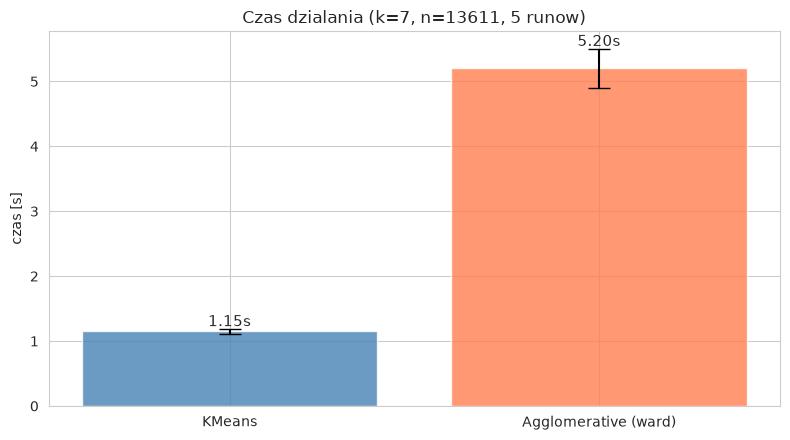

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(2)
ax.bar(x, [km_mean, agg_mean], yerr=[km_std, agg_std], capsize=8,
       color=['steelblue', 'coral'], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['KMeans', 'Agglomerative (ward)'])
ax.set_ylabel('czas [s]')
ax.set_title(f'Czas dzialania (k={k_time}, n={X.shape[0]}, {n_runs} runow)')
for i, (m, s) in enumerate(zip([km_mean, agg_mean], [km_std, agg_std])):
    ax.text(i, m + s + 0.05, f'{m:.2f}s', ha='center', fontsize=11)
plt.tight_layout(); plt.show()

k=3: KMeans=1.05s, Agglomerative=4.94s


k=7: KMeans=1.07s, Agglomerative=5.69s


k=12: KMeans=1.28s, Agglomerative=6.07s


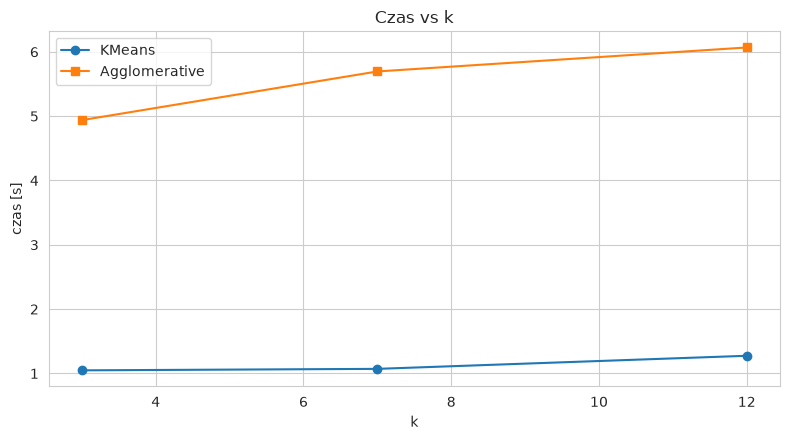

In [24]:
k_for_time = [3, 7, 12]
time_vs_k = {'KMeans': [], 'Agglomerative': []}
for k in k_for_time:
    t_km, _, _ = measure_time(lambda k=k: KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(X),
                              n_runs=3, warmup=1)
    time_vs_k['KMeans'].append(t_km)
    t_agg, _, _ = measure_time(lambda k=k: AgglomerativeClustering(n_clusters=k, metric='euclidean',
                                                                    linkage='ward').fit(X),
                               n_runs=3, warmup=1)
    time_vs_k['Agglomerative'].append(t_agg)
    print(f'k={k}: KMeans={t_km:.2f}s, Agglomerative={t_agg:.2f}s')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_for_time, time_vs_k['KMeans'], marker='o', label='KMeans')
ax.plot(k_for_time, time_vs_k['Agglomerative'], marker='s', label='Agglomerative')
ax.set_xlabel('k'); ax.set_ylabel('czas [s]'); ax.set_title('Czas vs k')
ax.legend()
plt.tight_layout(); plt.show()

## Wnioski

Zbior: 13611 ziaren, 16 cech na roznych skalach (StandardScaler konieczny), 7 klas mocno niezbalansowanych (DERMASON 3546 vs BOMBAY 522). Wiele cech silnie skorelowanych (Area/ConvexArea r=1.0, Compactness/ShapeFactor3 r=0.999) - wynika z geometrii ziarna. W rzucie PCA BOMBAY i BARBUNYA odseparowane, DERMASON/SIRA sie mieszaja.

KMeans vs Agglomerative (ward): metryki bardzo zblizone dla k=7 (silhouette ~0.28, purity ~0.88). Oba algorytmy odkryja strukture zgodna z gatunkami. Silhouette max dla malych k (2-3) bo jeden klastrow to BOMBAY-reszta. Purity rosnie az do k=7 i sie stabilizuje. Z innych strategii aglomeracyjnych - ward i complete podobnie, average gorzej, single znacznie gorzej (lancuchowanie).

Optymalne k: nie ma jednej wartosci. Elbow ~k=4-5, silhouette sugeruje k=2-3, purity k=7. Wybor zalezy od celu - w praktyce laczysz kilka miar i wiedze domenowa.

Czas: KMeans ~1.0s, Agglomerative ~4.6s dla n=13611, k=7 (Agglomerative ~4.4x wolniej). KMeans O(n*k*d*i), Agglomerative ward O(n^2 log n) na macierzy odleglosci. KMeans rosnie liniowiej z k, Agglomerative prawie wcale (bo ciecie dendrogramu jest darmowe - najwiecej czasu kosztuje budowa calego drzewa). Dla duzych zbiorow KMeans lepszy, aglomeracyjny lepszy dla malych gdzie chcemy dendrogram.